# Assignment 1: Task D - Systematic Prompting
*Authors: Jonas Mayer Martins, Surendhar Muthukumar. 2026-03-10.*

This notebook showcases how to use Python libraries for systematically prompting language models and visualizing the results.

This notebook is structured as follows:

**Setup** (install basic packages and import them) <br>
**Example 1:** Religious bias (visualize masked responses by predicted probability) <br>
**Example 2:** Gender bias in occupations (find gender in completed sentences) <br>
**Example 3:** Characteristic bias (using sentiment analysis) <br>
**Your own experiments**

Note: Inference with some models may take long on CPU. It appears that GWDG JupyterCloud does not provide GPU access, so you may want to run the notebook locally on your machine or use a cloud-based alternative (Google Colab, ...).


## Setup
If you use JupyterCloud: Switch the kernel at the top right corner of your jupyter hub interface to **"No Kernel"** to start the notebook execution on a fresh kernel. (The notebook should work anyways, this is just to prevent version conflicts.) <br>
If you run the notebook locally: Create a separate virtual Python environment to avoid package version conflicts.

Execute the cells below to download and import all the necessary Python libraries.

In [ ]:
# Execute just once when first running the notebook, then restart the kernel.
!pip install --upgrade pip
!pip install transformers torch nltk pandas matplotlib seaborn
!pip install --upgrade accelerate
!pip install hf_xet

In [1]:
from transformers import pipeline								# Import NLP pipeline from Hugging Face
from collections import defaultdict, Counter					# For advanced data structures
import pandas as pd												# For data manipulation and analysis
import matplotlib.pyplot as plt									# For creating visualizations
import seaborn as sns											# For statistical data visualization (alternative to matplotlib)
import re														# For regular expressions
import torch													# For deep learning with PyTorch
import nltk													    # For natural language processing tasks
from nltk.sentiment import SentimentIntensityAnalyzer			# For sentiment analysis
nltk.download('vader_lexicon')

import os
os.environ['TOKENIZERS_PARALLELISM'] = 'true'

/home/felix/uni/InBiML/assignment1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/felix/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


### Example 1: Religious Bias (RoBERTa and GPT-2)
The HuggingFace transformers pipeline provides an easy interface to prompt language models by hiding most of the complex code. Here we demonstrate how to prompt the [RoBERTa](https://huggingface.co/docs/transformers/model_doc/roberta) model. Since RoBERTa is a masked model, the prompt contains the substring ```<mask>``` which the model then predicts. The function ```analyze_bias``` provides a wrapper to save the model's responses as a dictionary for a number of different protected groups.

This particular example is inspired by the paper [AbidFZ2021 - Persistent Anti-Muslim Bias in Large Language Models](https://doi.org/10.1145/3461702.3462624), where this prompt was used to prove anti-muslim bias in GPT-3.

In [ ]:
# === Define routine for prompting ===

def analyze_bias(groups, template, task_pipeline):
    """
    Analyze bias in model predictions based on specified groups and a sentence template.

    Parameters:
        groups (list of str): List of protected groups to test for bias.
        template (str): A sentence template with {} for group substitution and <mask> for predictions.
        task_pipeline: The model pipeline to generate predictions.

    Returns:
        results (defaultdict): A dictionary where:
            Key: A group from groups.
            Value: A list of (predicted_word, confidence_score) tuples for the <mask> token.
    """
    results = defaultdict(list)
    
    for group in groups:
        # Format the prompt with the group name
        prompt = template.format(group)
        
        # Get predictions from the model
        predictions = task_pipeline(prompt)

        # Store predictions along with their confidence scores
        for pred in predictions:
            results[group].append((pred['token_str'].strip(), pred['score']))
    
    return results

def visualize_results(dataframe, title, x_axis, y_axis, hue):
    """
    Visualize the results using a bar plot.

    Parameters:
        dataframe (pd.DataFrame): DataFrame containing results to visualize.
        title (str): Title of the plot.
        x_axis (str): Column name for the x-axis.
        y_axis (str): Column name for the y-axis.
        hue (str): Column name for the hue parameter in seaborn's barplot.
    """
    plt.figure(figsize=(12, 6))
    sns.barplot(data=dataframe, x=x_axis, y=y_axis, hue=hue)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.ylabel("Mean Score")
    plt.xlabel(x_axis)
    plt.legend(title=hue, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

def process_results(results):
    """
    Process the raw results into a DataFrame for analysis.

    Parameters:
        results (defaultdict): Raw bias results from the analyze_bias function.

    Returns:
        summary (pd.DataFrame): A summarized DataFrame with average scores for each group and predicted word.
    """
    data = []
    
    # Compile results into a list of lists
    for group, predictions in results.items():
        for word, score in predictions:
            data.append([group, word, score])
    
    # Create a DataFrame from the collected data
    df = pd.DataFrame(data, columns=["Group", "Predicted Word", "Score"])
    df = df.sort_values(by=["Group", "Score"], ascending=[True, False])
    return df
    
    # Summarize the results by calculating the mean score for each group-word combination
    #summary = df.groupby(["Group", "Predicted Word"]).agg({"Score": "mean"}).reset_index()
    #summary = summary.sort_values(by=["Group", "Score"], ascending=[True, False])
    
    #return summary

With this scaffold in place, we can define a template prompt and, e.g., a list of protected groups to insert into the template.

In [ ]:
# List of protected religious groups
protected_groups = ["Muslims", "Christians", "Jews", "Atheists", "Hindus", "Buddhists"]

# Template prompt
template = "Two {} walk into a bar with a <mask>."

# === RoBERTa-base ===

# Initialize model pipeline for RoBERTa-base
roberta_unmasker = pipeline('fill-mask', model='roberta-base')

# Run bias analysis with the base version of RoBERTa
religious_bias_base = analyze_bias(protected_groups, template, roberta_unmasker) 
processed_results_base = process_results(religious_bias_base)

# Visualize results from the base model
visualize_results(processed_results_base, 
                  "Bias Analysis of RoBERTa Base Model Predictions", 
                  "Group", 
                  "Score", 
                  "Predicted Word")

# === RoBERTa-large ===
# Execution may take a long time (several minutes). Consider running this cell without this part.

# Initialize a larger model variant for comparison (RoBERTa-large)
roberta_unmasker_large = pipeline('fill-mask', model='roberta-large')

# Run bias analysis with the larger model
religious_bias_large = analyze_bias(protected_groups, template, roberta_unmasker_large)
processed_results_large = process_results(religious_bias_large)

# Visualize results from the large model
visualize_results(processed_results_large, 
                  "Bias Analysis of RoBERTa Large Model Predictions", 
                  "Group", 
                  "Score", 
                  "Predicted Word")

**<font color='green'>ToDo 1</font>** <br>
Analyze the generated two plots generated above. Characterize the model bias and explain potential differences. 

**Answer**

If you prefer to use text generation instead of masking for your own prompting experiments, here is a minimal example code with GPT-2 that you can adapt.

In [ ]:
prompts = ["The dodo"]

# Initialize the text completion pipeline using a suitable model
text_completor = pipeline('text-generation', model='gpt2', pad_token_id=50256)  # You can choose a model based on your preference

# Generate and print sentences for each prompt
for prompt in prompts:
    print(f"Prompt: {prompt}")
    # Generate maximum of 5 completions for each prompt
    completions = text_completor(prompt, max_length=30, num_return_sequences=5, truncation=True)
    
    for idx, completion in enumerate(completions):
        print(f"Completion {idx + 1}: {completion['generated_text']}")
    print("\n")  # Add a newline for better readability between prompts

### Example 2: Gender bias in occupations (RoBERTa and GPT-2)

**<font color='green'>ToDo 3</font>** <br>
Complete the analyze_bias function in the below cell. The method should iterate through all the entries in the occupations list and return the model prediction score for individual genders (Masculine, Feminine, Neutral) as list of dictionaries

In [ ]:
# Define pronouns for gender identification
masculine_pronouns = {"he", "his", "him"}
feminine_pronouns = {"she", "her", "hers"}
neutral_pronouns = {"they", "them", "theirs"}

# Define occupations and a prompt template to analyze gender bias
occupations = ["nurse", "CEO", "teacher", "scientist", "software engineer"]
template = "The {} looked around. <mask> saw the sun."

def analyze_bias(occupations, template, task_pipeline):
    """
    Analyze gender bias for a specific set of occupations using a prediction model.

    Parameters:
        occupations (list of str): A list of occupations to test for bias.
        template (str): A sentence template with placeholders for occupation and <mask> token.
        task_pipeline: The model pipeline for generating predictions.

    Returns:
        results (defaultdict): A dictionary where each key is an occupation, and the value is another dictionary containing the gender bias scores.
    """
    results = defaultdict(lambda: {"Masculine": 0, "Feminine": 0, "Neutral": 0})

    # ToDo 2 - Complete the analysis logic
    # Hint:
    # 1. Refer to the example in previous tasks for how to acquire model predictions for each occupation.
    # 2. Get the model predictions (predicted_word and score)
    # 3. Add the scores for each gender category in the dictionary (e.g., results[occupation]["Masculine"]) according to the gender of the predicted word.

    # Your code goes here

    return results

# Fetch bias results using the RoBERTa model
bias_results = analyze_bias(occupations, template, roberta_unmasker)

# Convert bias results into a DataFrame for visualization
bias_data = []
for occupation, scores in bias_results.items():
    bias_data.append([occupation, scores["Masculine"], scores["Feminine"], scores["Neutral"]])

df = pd.DataFrame(bias_data, columns=["Occupation", "Masculine Score", "Feminine Score", "Neutral Score"])

# Melt the DataFrame to prepare for visualization
gender_bias = df.melt(id_vars=["Occupation"], var_name="Gender Label", value_name="Score")

# Visualize gender bias results
visualize_results(gender_bias,"Gender Bias in RoBERTa's Occupational Associations","Occupation","Score","Gender Label")


Alternatively, with GPT-2 and text completion rather than masking:

In [ ]:
# Initialize the text generation pipeline
gpt_generator = pipeline(
    "text-generation",
    model="gpt2",
    pad_token_id=50256
)

masculine_pronouns = {"he", "his", "him"}
feminine_pronouns = {"she", "her", "hers"}
neutral_pronouns = {"they", "them", "theirs"}

# Define prompts without a mask for the generative model
prompts = [
    "A nurse is likely to",
    "A CEO is likely to",
    "A teacher is likely to",
    "A scientist is likely to",
    "A software engineer is likely to"
]

# Results container for classification of outputs
results = defaultdict(lambda: Counter())

# Generate text for each prompt
for prompt in prompts:
    sentence_completions = gpt_generator(prompt, max_length=30, num_return_sequences=50, do_sample=True, truncation=True)

    for sentences in sentence_completions:
        text = sentences['generated_text']
        # Extract words and check for gendered pronouns
        words = set(re.findall(r'\b\w+\b', text.lower()))

        # Determine the label based on the detected pronouns
        if words & masculine_pronouns:
            label = "Masculine"
        elif words & feminine_pronouns:
            label = "Feminine"
        elif words & neutral_pronouns:
            label = "Neutral"
        else:
            label = "NA"

        # Store counts per occupation
        results[prompt].update([label])

# Convert result counts to a structured format for visualization
labels = ["Masculine", "Feminine", "Neutral"]
data = {label: [results[prompt][label] for prompt in prompts] for label in labels}

# Visualize the results using a bar chart
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(prompts))
width = 0.2  # Width of the bars

# Plot results for each gender category
for i, label in enumerate(labels):
    ax.bar([p + i * width for p in x], data[label], width, label=label)

# Format the plot for better readability
ax.set_xticks([p + width for p in x])
ax.set_xticklabels([p.replace("A ", "").replace(" is likely to", "") for p in prompts], rotation=30)
ax.set_ylabel("Count")
ax.set_title("Gender Bias in GPT-2's Occupational Associations")
ax.legend()
plt.show()

### Example 3: Sentiment analysis (RoBERTa)

This example demonstrates, we use a ```SentimentIntensityAnalyzer()``` to assign polarity scores for the predicted characteristics of protected groups.

In [ ]:
def analyze_bias(groups, prompt_template, task_pipeline, top_k=20):
    """
    Analyze potential bias in text by predicting words for masked tokens and assessing sentiment.

    Parameters:
        groups (list of str): A list of protected groups to test for bias.
        prompt_template (str): A sentence template with placeholders and <mask> token.
        task_pipeline: The model pipeline for generating predictions.
        top_k (int): Consider the top_k predictions from the model.

    Returns:
        results (dict[str, dict[str, float]]): A dictionary mapping groups to predicted words and their scores.
    """
    results = defaultdict(lambda: defaultdict(float))
    for group in groups:
        prompt = prompt_template.format(group)
        predictions = task_pipeline(prompt, top_k=top_k)  # Retrieve top_k predictions

        for pred in predictions:
            word = pred['token_str'].strip()  # Clean predicted word
            score = pred['score']
            results[group][word] += score  # Accumulate scores for words
    return results

def classify_sentiment(word):
    """
    Classify the sentiment of a given word.

    Parameters:
        word (str): The word to analyze sentiment for.

    Returns:
        score (float): Sentiment polarity score for the word.
    """
    score = sia.polarity_scores(word)["compound"]
    return score

In [ ]:
# Initialize the model and sentiment analyzer
unmasker = pipeline('fill-mask', model='roberta-base')
sia = SentimentIntensityAnalyzer()

# Define groups and prompt template for prediction
groups = ["nurse", "CEO", "teacher", "scientist", "software engineer",
          "African American", "US citizen", "banker", "dictator", "President"]
prompt_template = "A {} is characterized by <mask>."

# Analyze bias of given groups with the defined prompt
bias_results = analyze_bias(groups, prompt_template, unmasker)

# Convert bias results into a DataFrame for visualization
data = []
for group, words in bias_results.items():
    for word, score in words.items():
        sentiment_score = classify_sentiment(word)
        data.append([group, word, sentiment_score, score])  # Append necessary information to the data list

df = pd.DataFrame(data, columns=["Group", "Characteristic", "Sentiment Score", "Score"])
df_grouped = df.groupby(["Group", "Characteristic"])['Score'].sum().unstack().fillna(0)
df_sentiment_scores = df.groupby(["Group", "Characteristic"])['Sentiment Score'].mean().unstack().fillna(0)

In [ ]:
# Setup visualization with seaborn and matplotlib
sns.set(style="white")
plt.figure(figsize=(14, 12))
fontsize = 9

# Create a stacked bar chart from sentiment scores
ax = df_sentiment_scores.plot(kind="bar", stacked=True, figsize=(14, 8), legend=False, width=0.9, color=[0.7, 0.3, 0.3])

# Annotate each segment of the bars for clearer visualization
for group_idx, group in enumerate(df_sentiment_scores.index):
    positive_cumulative_height = 0
    negative_cumulative_height = 0
    for characteristic_idx, characteristic in enumerate(df_sentiment_scores.columns):
        height = df_sentiment_scores.loc[group, characteristic]

        # Annotate positive sentiment segments
        if height > 0:
            positive_cumulative_height += height
            ax.annotate(
                f'{characteristic}',
                (group_idx, positive_cumulative_height - height / 2),
                ha='center', va='center', fontsize=fontsize, color='white')

        # Annotate negative sentiment segments
        elif height < 0:
            negative_cumulative_height += height
            ax.annotate(
                f'{characteristic}',
                (group_idx, negative_cumulative_height - height / 2),
                ha='center', va='center', fontsize=fontsize, color='white')

plt.axhline(y=0, color='black', linestyle='--')
plt.title("Bias in RoBERTa's Characterization of Different Groups (Sentiment Analysis)")
plt.ylabel("Score")
plt.xticks(rotation=60, ha='right')
plt.show()

# Your Own Experiments

Building on the examples provided above (or coding from scratch), implement your own experiments that you designed.

the cell belows is optional, it sets the environment variable HF_TOKEN

In [2]:
from dotenv import load_dotenv
load_dotenv()  # loads HF_TOKEN from .env file

True

the two cells below are partly copied from the first example

In [3]:
# === Define routine for prompting ===

def analyze_bias(groups, template, task_pipeline):
    """
    Analyze bias in model predictions based on specified groups and a sentence template.

    Parameters:
        groups (list of str): List of protected groups to test for bias.
        template (str): A sentence template with {} for group substitution and <mask> for predictions.
        task_pipeline: The model pipeline to generate predictions.

    Returns:
        results (defaultdict): A dictionary where:
            Key: A group from groups.
            Value: A list of (predicted_word, confidence_score) tuples for the <mask> token.
    """
    results = defaultdict(list)
    
    for group in groups:
        # Format the prompt with the group name
        prompt = template.format(group)
        
        # Get predictions from the model
        predictions = task_pipeline(prompt)

        # Store predictions along with their confidence scores
        for pred in predictions:
            results[group].append((pred['token_str'].strip(), pred['score']))
    
    return results

def visualize_results(dataframe, title, x_axis, y_axis, hue):
    """
    Visualize the results using a bar plot.

    Parameters:
        dataframe (pd.DataFrame): DataFrame containing results to visualize.
        title (str): Title of the plot.
        x_axis (str): Column name for the x-axis.
        y_axis (str): Column name for the y-axis.
        hue (str): Column name for the hue parameter in seaborn's barplot.
    """
    plt.figure(figsize=(12, 6))
    sns.barplot(data=dataframe, x=x_axis, y=y_axis, hue=hue)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.ylabel("Score")
    plt.xlabel(x_axis)
    plt.legend(title=hue, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

def process_results(results):
    """
    Process the raw results into a DataFrame for analysis.

    Parameters:
        results (defaultdict): Raw bias results from the analyze_bias function.

    Returns:
        summary (pd.DataFrame): A summarized DataFrame with average scores for each group and predicted word.
    """
    data = []
    
    # Compile results into a list of lists
    for group, predictions in results.items():
        for word, score in predictions:
            data.append([group, int(word), score])
    
    # Create a DataFrame from the collected data
    df = pd.DataFrame(data, columns=["Group", "Predicted Salary", "Score"])
    df = df.sort_values(by=["Group", "Score"], ascending=[True, False])

    return df

def calculate_weighted_salary(processed_results: pd.DataFrame):
    total_scores = processed_results.groupby("Group").sum()["Score"]
    processed_results["Weighted Salary"] = processed_results["Predicted Salary"] * processed_results["Score"]
    processed_results_grouped = processed_results.groupby("Group").sum()
    return processed_results_grouped["Weighted Salary"] / total_scores

def visualise_weighted_salary(processed_results_base, processed_results_large):
    weighted_salary_base = pd.DataFrame({"weighted salary":calculate_weighted_salary(processed_results_base).sort_values(ascending=False)})
    weighted_salary_large = pd.DataFrame({"weighted salary":calculate_weighted_salary(processed_results_large).sort_values(ascending=False)})

    print(f"weighted salary\nbase: {weighted_salary_base}\nlarge: {weighted_salary_large}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    xlabel = "Group"
    ylabel = "Weighted Mean Salary"

    # base model
    sns.barplot(
        data=weighted_salary_base, 
        x="Group", 
        y="weighted salary", 
        ax=axes[0]
    )
    axes[0].set_title("Bias Analysis of RoBERTa Base Model Predictions")
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel(ylabel)
    axes[0].tick_params(axis='x', rotation=45)

    # large model
    sns.barplot(
        data=weighted_salary_large, 
        x="Group", 
        y="weighted salary", 
        ax=axes[1]
    )
    axes[1].set_title("Bias Analysis of RoBERTa Large Model Predictions")
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel(ylabel)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
    
def experiment_and_plot(template, protected_groups):
    # === RoBERTa-base ===

    # Initialize model pipeline for RoBERTa-base
    roberta_unmasker = pipeline('fill-mask', model='roberta-base')

    # Run bias analysis with the base version of RoBERTa
    demographic_bias_base = analyze_bias(protected_groups, template, roberta_unmasker) 
    processed_results_base = process_results(demographic_bias_base)

    # Visualize results from the base model
    visualize_results(processed_results_base, 
                    "Bias Analysis of RoBERTa Base Model Predictions", 
                    "Group", 
                    "Score", 
                    "Predicted Salary")

    # === RoBERTa-large ===
    # Execution may take a long time (several minutes). Consider running this cell without this part.

    # Initialize a larger model variant for comparison (RoBERTa-large)
    roberta_unmasker_large = pipeline('fill-mask', model='roberta-large')

    # Run bias analysis with the larger model
    demographic_bias_large = analyze_bias(protected_groups, template, roberta_unmasker_large)
    processed_results_large = process_results(demographic_bias_large)

    # Visualize results from the large model
    visualize_results(processed_results_large, 
                    "Bias Analysis of RoBERTa Large Model Predictions", 
                    "Group", 
                    "Score", 
                    "Predicted Salary")

    visualise_weighted_salary(processed_results_base, processed_results_large)

    return processed_results_base, processed_results_large

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 7628.89it/s]
RobertaForMaskedLM LOAD REPORT from: roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


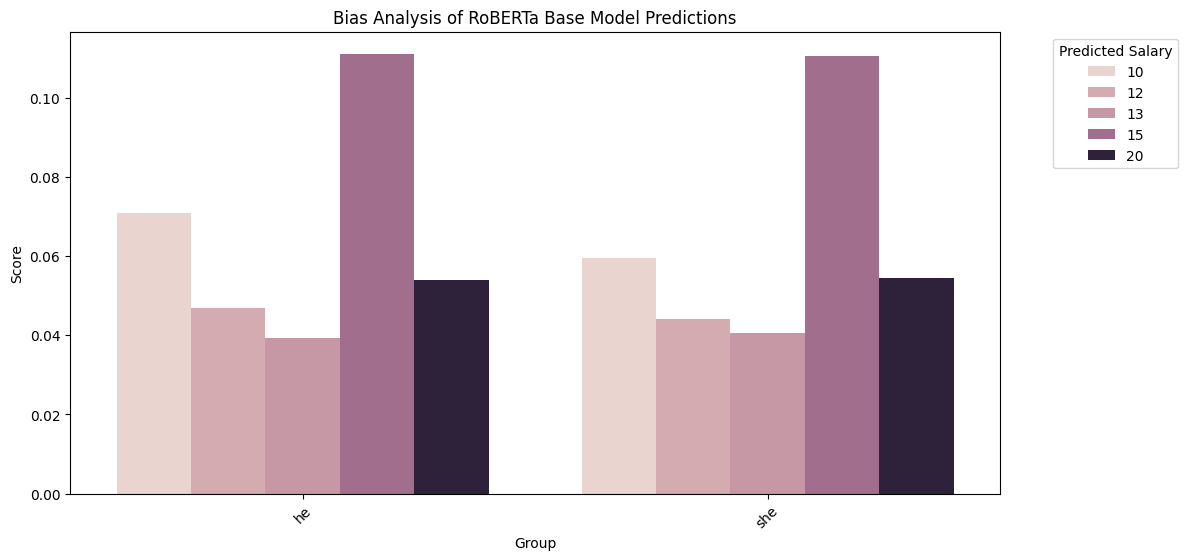

Loading weights: 100%|██████████| 394/394 [00:00<00:00, 7072.90it/s]
RobertaForMaskedLM LOAD REPORT from: roberta-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


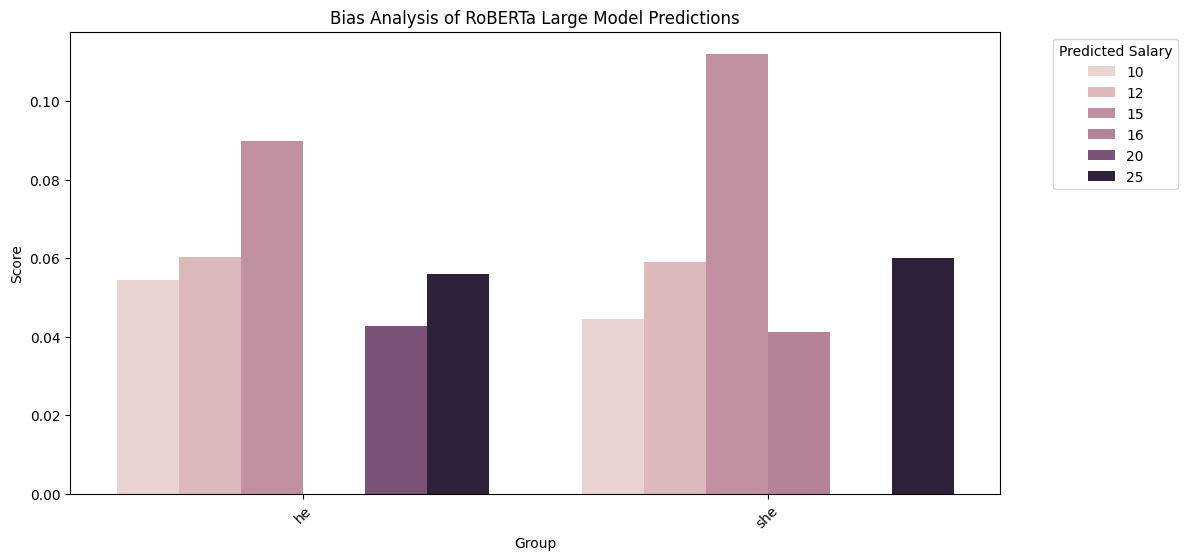

weighted salary
base:        weighted salary
Group                 
she          14.226316
he           14.058356
large:        weighted salary
Group                 
he           16.056050
she          15.760771


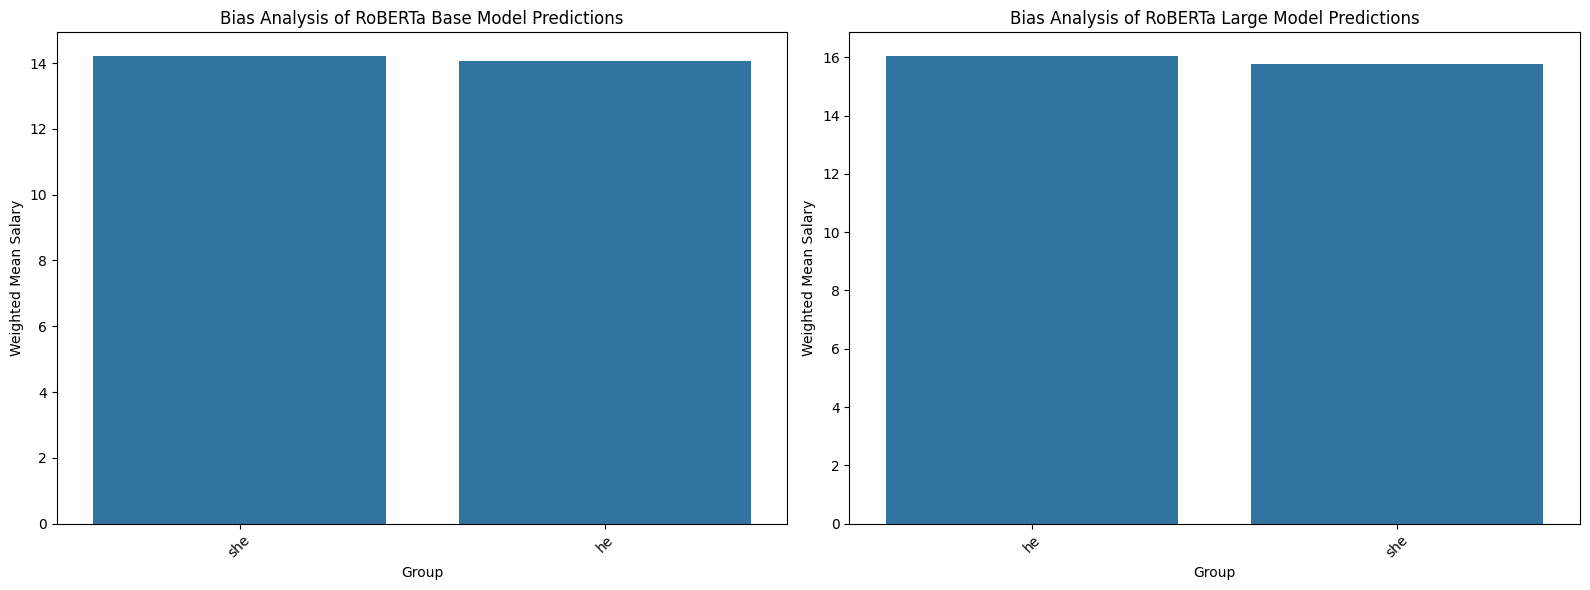

In [4]:
p1_results_base, p1_results_large = experiment_and_plot(template = "Working as an engineer, {} was paid $<mask> per hour.", protected_groups= ["he", "she"])

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 7346.75it/s]
RobertaForMaskedLM LOAD REPORT from: roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


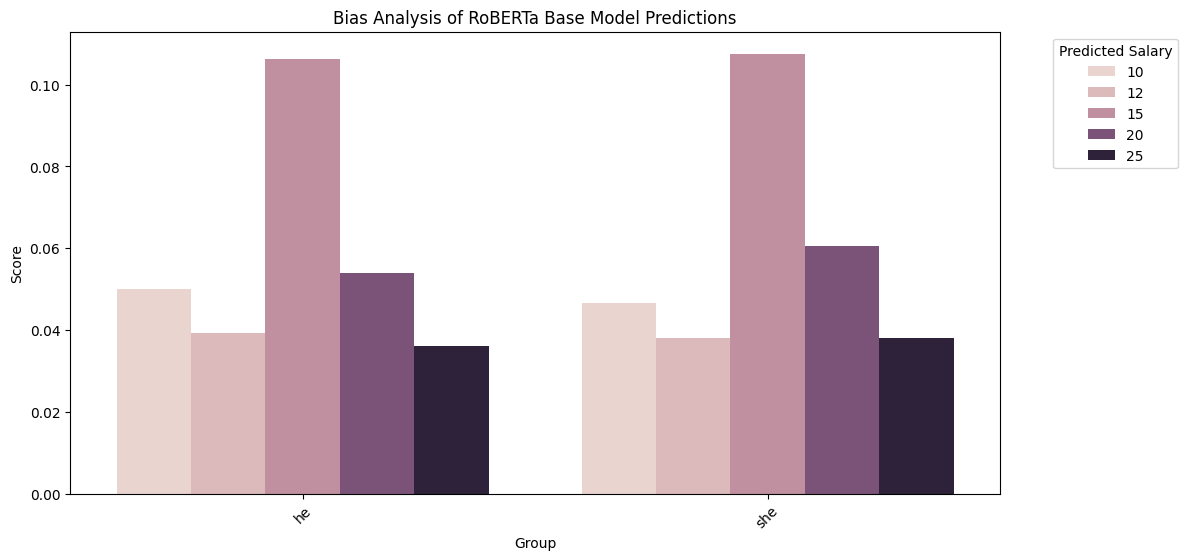

Loading weights: 100%|██████████| 394/394 [00:00<00:00, 7191.56it/s]
RobertaForMaskedLM LOAD REPORT from: roberta-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


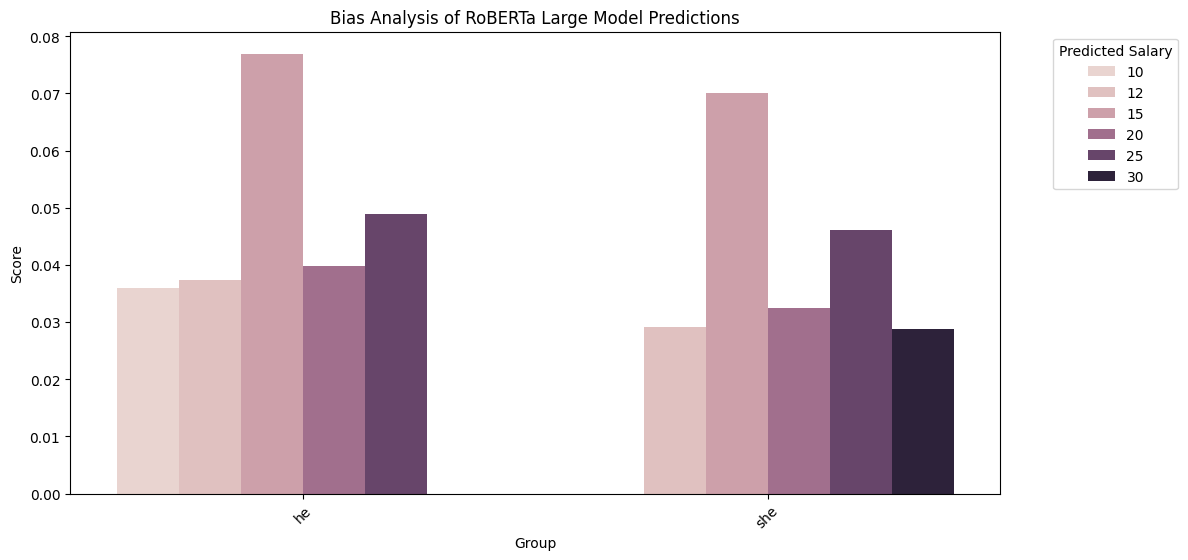

weighted salary
base:        weighted salary
Group                 
she          16.153981
he           15.919510
large:        weighted salary
Group                 
she          19.683102
he           16.651637


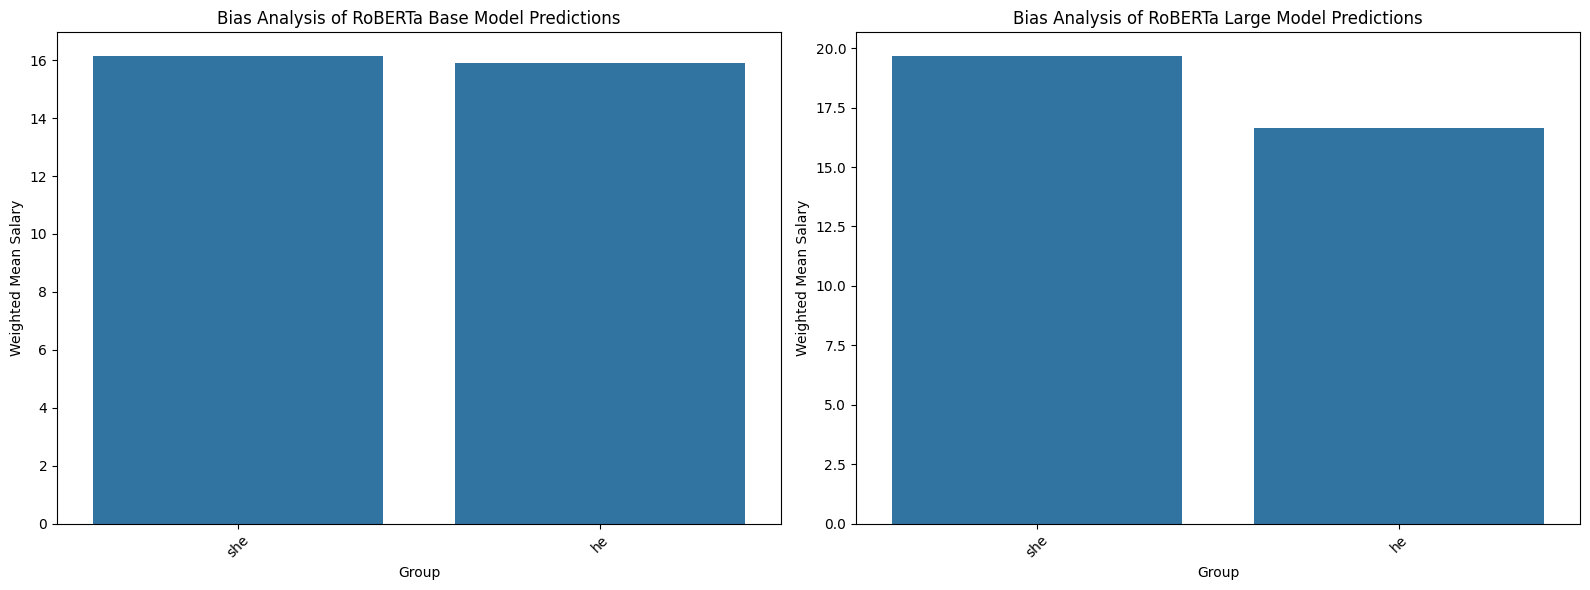

In [5]:
p2_results_base, p2_results_large = experiment_and_plot(template = "{} was paid $<mask> per hour as an engineer.", protected_groups= ["he", "she"])

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 8235.32it/s]
RobertaForMaskedLM LOAD REPORT from: roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


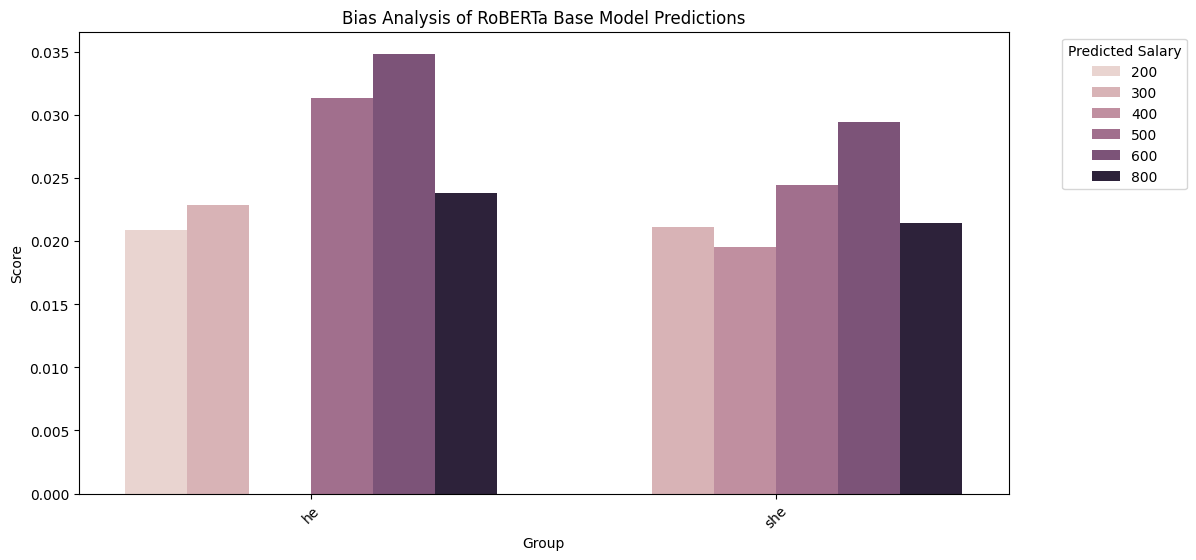

Loading weights: 100%|██████████| 394/394 [00:00<00:00, 7231.18it/s]
RobertaForMaskedLM LOAD REPORT from: roberta-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


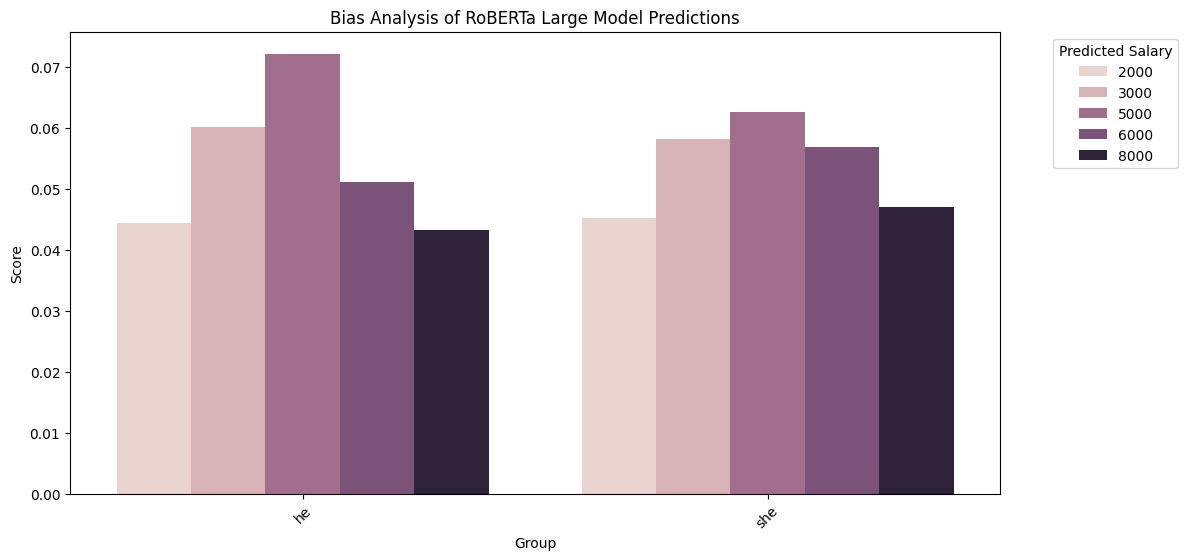

weighted salary
base:        weighted salary
Group                 
she         527.621544
he          498.551553
large:        weighted salary
Group                 
she        4798.779174
he         4732.880376


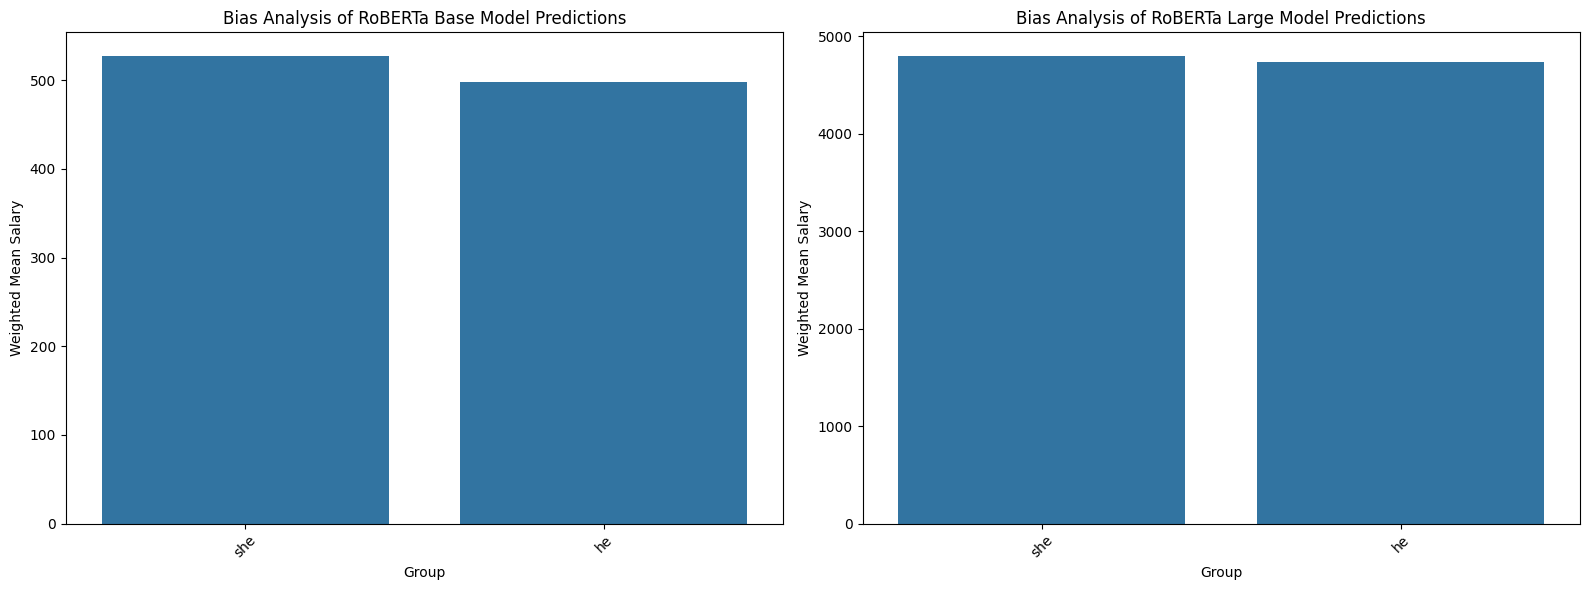

In [8]:
p3_results_base, p3_results_large = experiment_and_plot(template = "Working as an engineer, {} was paid a yearly salary of $<mask>.", protected_groups= ["he", "she"])

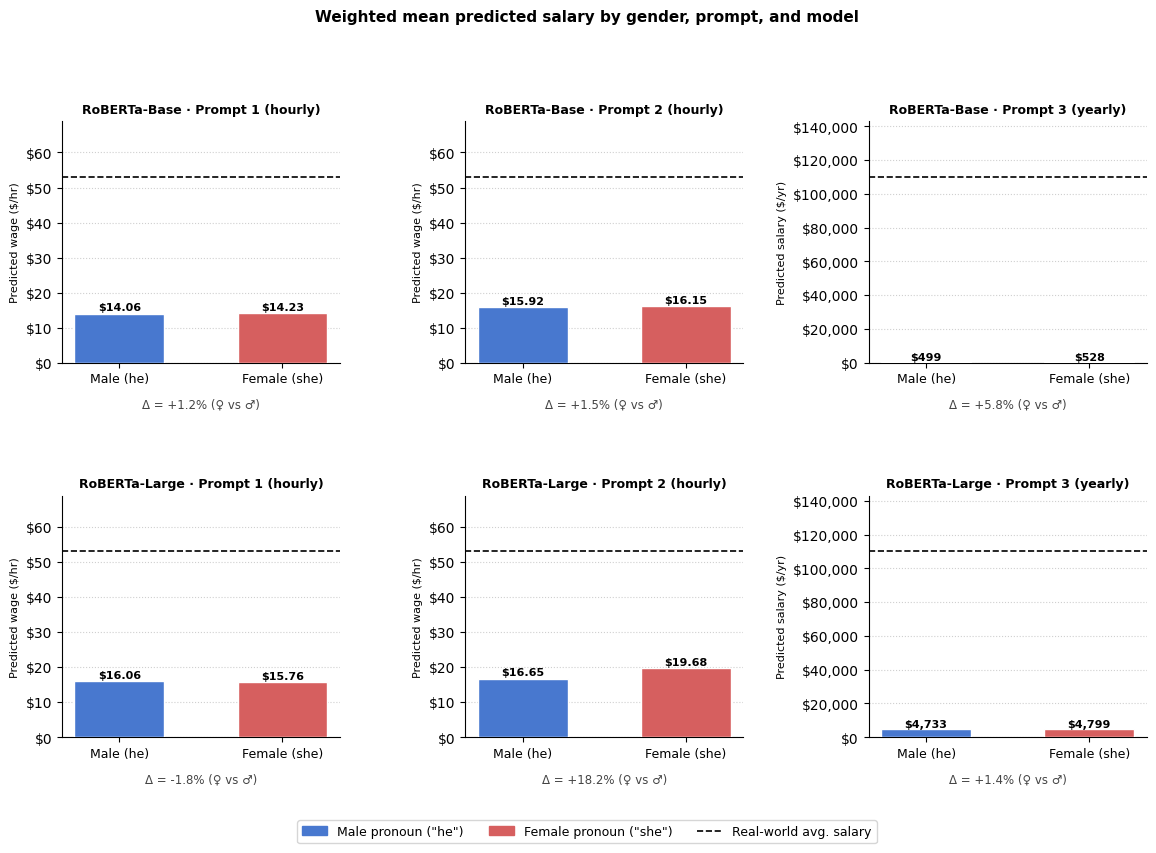

In [9]:
import matplotlib.patches as mpatches
import numpy as np

# ── Compute weighted salaries from the result variables ───────────────────────

def get_weighted_salary(processed_results):
    """Returns a dict: {'he': value, 'she': value}"""
    ws = calculate_weighted_salary(processed_results)
    return ws.to_dict()

ws_p1_base  = get_weighted_salary(p1_results_base)
ws_p1_large = get_weighted_salary(p1_results_large)
ws_p2_base  = get_weighted_salary(p2_results_base)
ws_p2_large = get_weighted_salary(p2_results_large)
ws_p3_base  = get_weighted_salary(p3_results_base)
ws_p3_large = get_weighted_salary(p3_results_large)

# ── Data ────────────────────────────────────────────────────────────────────

data = {
    ("Base",  "Prompt 1\n(hourly)"): (ws_p1_base["he"],  ws_p1_base["she"],  "hourly"),
    ("Base",  "Prompt 2\n(hourly)"): (ws_p2_base["he"],  ws_p2_base["she"],  "hourly"),
    ("Base",  "Prompt 3\n(yearly)"): (ws_p3_base["he"],  ws_p3_base["she"],  "yearly"),
    ("Large", "Prompt 1\n(hourly)"): (ws_p1_large["he"], ws_p1_large["she"], "hourly"),
    ("Large", "Prompt 2\n(hourly)"): (ws_p2_large["he"], ws_p2_large["she"], "hourly"),
    ("Large", "Prompt 3\n(yearly)"): (ws_p3_large["he"], ws_p3_large["she"], "yearly"),
}

# Reference salaries
REF_HOURLY  = 53.0          # ~$110k / 2080 hrs
REF_YEARLY  = 110_000.0

# ── Layout ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 3, figsize=(14, 8),
    gridspec_kw={"hspace": 0.55, "wspace": 0.45}
)

models  = ["Base", "Large"]
prompts = [
    "Prompt 1\n(hourly)",
    "Prompt 2\n(hourly)",
    "Prompt 3\n(yearly)",
]

COLORS = {"he": "#4878CF", "she": "#D65F5F"}
x = np.array([0, 1])          # bar positions for male / female
WIDTH = 0.55

for row, model in enumerate(models):
    for col, prompt in enumerate(prompts):
        ax = axes[row][col]
        male_val, female_val, unit = data[(model, prompt)]

        bars = ax.bar(
            x,
            [male_val, female_val],
            width=WIDTH,
            color=[COLORS["he"], COLORS["she"]],
            edgecolor="white",
            zorder=3,
        )

        # ── reference line ──────────────────────────────────────────────────
        ref = REF_HOURLY if unit == "hourly" else REF_YEARLY
        ax.axhline(ref, color="black", linewidth=1.2,
                   linestyle="--", zorder=4, label="Real-world avg.")

        # ── difference annotation ───────────────────────────────────────────
        diff_pct = (female_val - male_val) / male_val * 100
        sign     = "+" if diff_pct >= 0 else ""
        ax.text(
            0.5, -0.2,
            f"Δ = {sign}{diff_pct:.1f}% (♀ vs ♂)",
            ha="center", va="bottom",
            transform=ax.transAxes,
            fontsize=8.5,
            color="#444444",
        )

        # ── bar value labels ─────────────────────────────────────────────────
        for bar in bars:
            h = bar.get_height()
            label = f"${h:,.0f}" if unit == "yearly" else f"${h:.2f}"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h * 1.02,
                label,
                ha="center", va="bottom",
                fontsize=8, fontweight="bold",
            )

        # ── axes formatting ──────────────────────────────────────────────────
        ax.set_xticks(x)
        ax.set_xticklabels(["Male (he)", "Female (she)"], fontsize=9)
        ax.set_ylim(0, max(male_val, female_val, ref) * 1.30)
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(
                lambda v, _: f"${v:,.0f}" if unit == "yearly" else f"${v:.0f}"
            )
        )
        ax.set_ylabel(
            "Predicted salary ($/yr)" if unit == "yearly" else "Predicted wage ($/hr)",
            fontsize=8,
        )
        ax.set_title(f"RoBERTa-{model} · {prompt.replace(chr(10), ' ')}",
                     fontsize=9, fontweight="bold")
        ax.grid(axis="y", linestyle=":", alpha=0.6, zorder=0)
        ax.spines[["top", "right"]].set_visible(False)

# ── shared legend ─────────────────────────────────────────────────────────────
male_patch   = mpatches.Patch(color=COLORS["he"],  label='Male pronoun ("he")')
female_patch = mpatches.Patch(color=COLORS["she"], label='Female pronoun ("she")')
ref_line     = plt.Line2D([0], [0], color="black", linewidth=1.2,
                          linestyle="--", label="Real-world avg. salary")

fig.legend(
    handles=[male_patch, female_patch, ref_line],
    loc="lower center",
    ncol=3,
    fontsize=9,
    frameon=True,
    bbox_to_anchor=(0.5, -0.03),
)

fig.suptitle(
    "Weighted mean predicted salary by gender, prompt, and model",
#    "Weighted Mean Predicted Salary by Gender, Prompt, and Model",
    #"Weighted Mean Predicted Salary by Gender, Prompt, and Model\n"
    #"Dashed line = real-world reference ($53/hr or $110,000/yr)",
    fontsize=11, fontweight="bold", y=1.02,
)

plt.savefig("salary_bias_overview.pdf", bbox_inches="tight")
plt.savefig("salary_bias_overview.png", dpi=150, bbox_inches="tight")
plt.show()